In [1]:
# STEP 1: Import required libraries

import pandas as pd
import numpy as np

# For visualization (optional but useful later)
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, mean_squared_error

In [3]:
# STEP 2: Load dataset

import pandas as pd

# Load UCI dataset (Math students file)
data = pd.read_csv("student/student-mat.csv", sep=";")

# Display first 5 rows
print("First 5 rows of dataset:")
print(data.head())

First 5 rows of dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [4]:
# Dataset structure
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object


In [5]:
# Missing values check
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [6]:
# Statistical summary
print("\nDataset Description:")
print(data.describe())


Dataset Description:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
std  

In [7]:
# STEP 3.1: Selecting features

features = ['studytime', 'failures', 'absences', 'G1', 'G2']

X = data[features]

print("Selected Features:")
print(X.head())

Selected Features:
   studytime  failures  absences  G1  G2
0          2         0         6   5   6
1          2         0         4   5   5
2          2         3        10   7   8
3          3         0         2  15  14
4          2         0         4   6  10


In [8]:
# STEP 3.2: Target variable for regression

y_regression = data['G3']

In [9]:
# STEP 3.3: Pass/Fail creation

data['pass_fail'] = data['G3'].apply(lambda x: 1 if x >= 10 else 0)

y_classification = data['pass_fail']

print("Pass/Fail distribution:")
print(data['pass_fail'].value_counts())

Pass/Fail distribution:
pass_fail
1    265
0    130
Name: count, dtype: int64


In [10]:
# STEP 3.4: Split dataset

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_classification, test_size=0.2, random_state=42
)

In [12]:
# STEP 4.1: Linear Regression Model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train_reg)

print("Linear Regression Model Trained ")

Linear Regression Model Trained 


In [13]:
# STEP 4.2: Predictions

y_pred_lr = lr_model.predict(X_test)

print("Sample Predictions:")
print(y_pred_lr[:10])

Sample Predictions:
[ 6.01113762 12.20306263  3.42583945  8.52243043  7.87300271 12.70478596
 18.6925959   7.10011213  7.22885591 12.6388124 ]


In [14]:
# STEP 4.3: Evaluation

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_reg, y_pred_lr)
r2 = r2_score(y_test_reg, y_pred_lr)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 4.466503212015605
R2 Score: 0.7821754247320556


In [16]:
# STEP 5.1: Logistic Regression Model

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train_cls, y_train_cls)

print("Logistic Regression Model Trained ")

Logistic Regression Model Trained 


In [17]:
# STEP 5.2: Predictions

y_pred_log = log_model.predict(X_test_cls)

print("Sample Predictions (Pass/Fail):")
print(y_pred_log[:10])

Sample Predictions (Pass/Fail):
[0 1 0 0 0 1 1 0 0 1]


In [18]:
# STEP 5.3: Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_cls, y_pred_log)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.8987341772151899


In [19]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_cls, y_pred_log)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[25  2]
 [ 6 46]]


In [20]:
# STEP 6.1: Create performance labels

def performance_label(mark):
    if mark < 10:
        return 0   # Low
    elif mark < 15:
        return 1   # Medium
    else:
        return 2   # High

data['performance'] = data['G3'].apply(performance_label)

y_tree = data['performance']

In [21]:
# STEP 6.2: Split data

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X, y_tree, test_size=0.2, random_state=42
)

In [22]:
# STEP 6.3: Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

tree_model.fit(X_train_tree, y_train_tree)

print("Decision Tree Model Trained ")

Decision Tree Model Trained 


In [23]:
# STEP 6.4: Predictions

y_pred_tree = tree_model.predict(X_test_tree)

print("Sample Predictions (Performance Class):")
print(y_pred_tree[:10])

Sample Predictions (Performance Class):
[0 1 0 1 1 1 2 0 0 1]


In [24]:
# STEP 6.5: Accuracy

accuracy_tree = accuracy_score(y_test_tree, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.8734177215189873


In [25]:
# STEP 7.1: Example student input

sample_input = [[2, 0, 4, 12, 13]]  
# format: [studytime, failures, absences, G1, G2]

In [28]:
# Predict final marks

pred_marks = lr_model.predict(sample_input)

print("Predicted Final Marks:", pred_marks[0])

Predicted Final Marks: 12.861765560024951


C:\Users\NAVYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [29]:
# Predict pass/fail

pred_pass_fail = log_model.predict(sample_input)

if pred_pass_fail[0] == 1:
    print("Result: PASS")
else:
    print("Result: FAIL")

Result: PASS


C:\Users\NAVYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [30]:
# Predict performance category

pred_perf = tree_model.predict(sample_input)

if pred_perf[0] == 0:
    print("Performance: LOW")
elif pred_perf[0] == 1:
    print("Performance: MEDIUM")
else:
    print("Performance: HIGH")

Performance: MEDIUM


C:\Users\NAVYA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


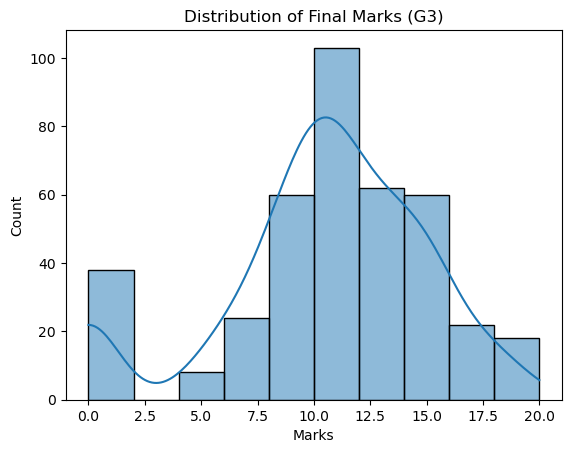

In [32]:
#STEP 8.1: Distribution of Final Marks (G3)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(data['G3'], bins=10, kde=True)
plt.title("Distribution of Final Marks (G3)")
plt.xlabel("Marks")
plt.ylabel("Count")
plt.show()

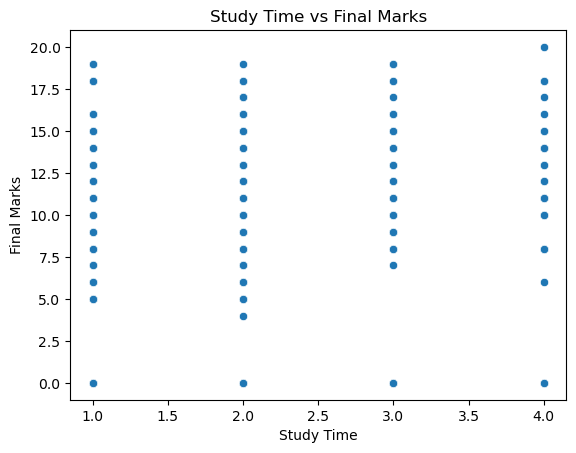

In [33]:
#STEP 8.2: Study Time vs Final Marks
plt.figure()
sns.scatterplot(x=data['studytime'], y=data['G3'])
plt.title("Study Time vs Final Marks")
plt.xlabel("Study Time")
plt.ylabel("Final Marks")
plt.show()

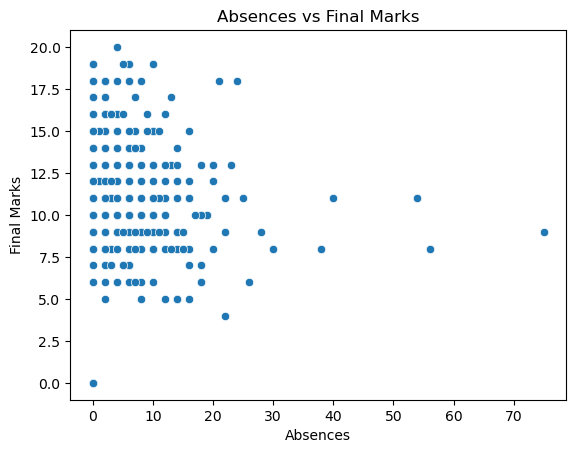

In [34]:
#STEP 8.3: Absences vs Final Marks
plt.figure()
sns.scatterplot(x=data['absences'], y=data['G3'])
plt.title("Absences vs Final Marks")
plt.xlabel("Absences")
plt.ylabel("Final Marks")
plt.show()

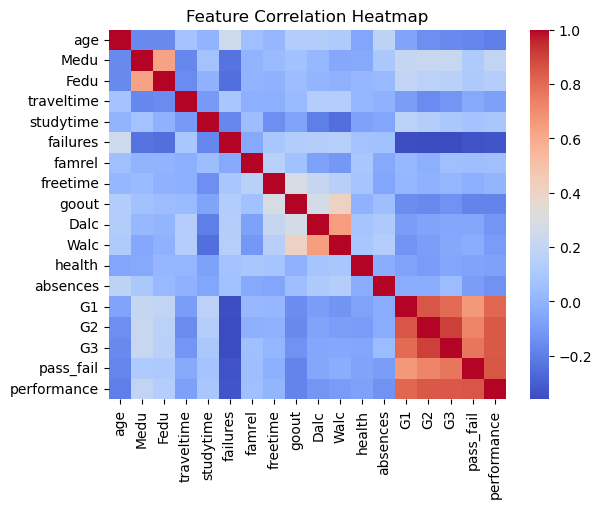

In [35]:
#STEP 8.4: Correlation Heatmap
plt.figure()
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

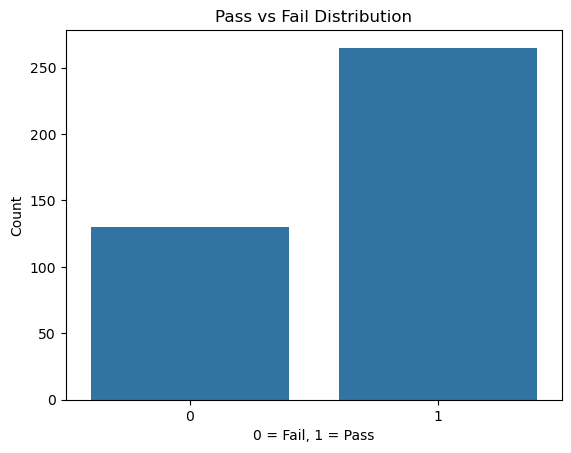

In [36]:
#STEP 8.5: Pass vs Fail Count
plt.figure()
sns.countplot(x=data['pass_fail'])
plt.title("Pass vs Fail Distribution")
plt.xlabel("0 = Fail, 1 = Pass")
plt.ylabel("Count")
plt.show()

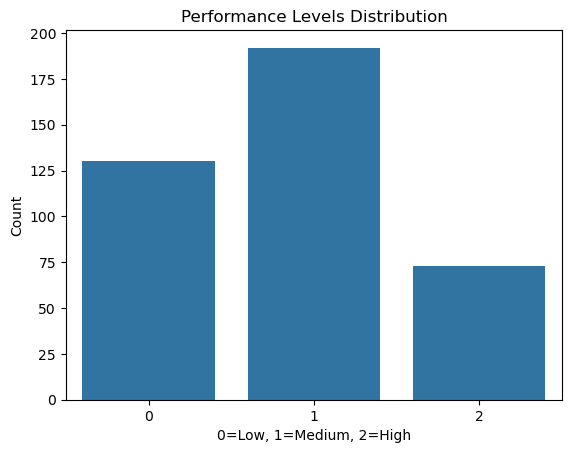

In [37]:
#STEP 8.6: Performance Level Distribution
plt.figure()
sns.countplot(x=data['performance'])
plt.title("Performance Levels Distribution")
plt.xlabel("0=Low, 1=Medium, 2=High")
plt.ylabel("Count")
plt.show()